# Static linear-encoding results

Load one or more `static_linear_encoding` result files and visualize score time courses. The saved arrays have shape `(neurons, timepoints)` for R² or `(1, timepoints)` for correlation.

In [11]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

ENV = os.getenv('MY_ENV', 'tiziano_mac_mini')
PROJECT_ROOT = Path.cwd().parents[1]
with open(PROJECT_ROOT / 'config.yaml', 'r') as file:
    paths = yaml.safe_load(file)[ENV]['paths']
RESULTS_DIR = Path(paths['data_path']) / 'results'
RESULTS_DIR

PosixPath('/Users/tizianocausin/metrics_II_local/results')

In [44]:
# Set these to the analysis configuration. Use '*' to leave a field unrestricted.
regression_type = 'ridge'
score_type = 'corr'       # 'r2' or 'corr'
cv_type = 'kf'          # 'same', 'loo', or 'kf'
preprocessing = 'raw'   # e.g. 'norm_feat_cnt', 'mean_cnt'
monkey_name = 'three0'
date = '250313'
brain_area = 'AIT'
model_name = 'vit_l_16'
img_size = 384
new_fs = 100

pattern = (
    f'static_linear_encoding_{regression_type}_{score_type}_{cv_type}_alpha*_'
    f'{preprocessing}_{monkey_name}_{date}_{brain_area}_{model_name}_'
    f'{img_size}_*_{new_fs}Hz.npz'
)
result_files = sorted(RESULTS_DIR.glob(pattern))
if not result_files:
    raise FileNotFoundError(f'No result files found for: {pattern}')
for index, result_file in enumerate(result_files):
    print(f'[{index}] {result_file.name}')

[0] static_linear_encoding_ridge_corr_kf_alpha1e-06to1000_n10_raw_three0_250313_AIT_vit_l_16_384_blocks.0.mlp.fc2_100Hz.npz
[1] static_linear_encoding_ridge_corr_kf_alpha1e-06to1000_n10_raw_three0_250313_AIT_vit_l_16_384_blocks.1.mlp.fc2_100Hz.npz
[2] static_linear_encoding_ridge_corr_kf_alpha1e-06to1000_n10_raw_three0_250313_AIT_vit_l_16_384_blocks.10.mlp.fc2_100Hz.npz
[3] static_linear_encoding_ridge_corr_kf_alpha1e-06to1000_n10_raw_three0_250313_AIT_vit_l_16_384_blocks.11.mlp.fc2_100Hz.npz
[4] static_linear_encoding_ridge_corr_kf_alpha1e-06to1000_n10_raw_three0_250313_AIT_vit_l_16_384_blocks.12.mlp.fc2_100Hz.npz
[5] static_linear_encoding_ridge_corr_kf_alpha1e-06to1000_n10_raw_three0_250313_AIT_vit_l_16_384_blocks.13.mlp.fc2_100Hz.npz
[6] static_linear_encoding_ridge_corr_kf_alpha1e-06to1000_n10_raw_three0_250313_AIT_vit_l_16_384_blocks.14.mlp.fc2_100Hz.npz
[7] static_linear_encoding_ridge_corr_kf_alpha1e-06to1000_n10_raw_three0_250313_AIT_vit_l_16_384_blocks.15.mlp.fc2_100Hz.npz
[8

In [45]:
# Select the layer/result to inspect.
result_index = 0
result_file = result_files[result_index]
scores = np.load(result_file)['arr_0']
if scores.ndim == 1:
    scores = scores[None, :]
time_ms = np.arange(scores.shape[-1]) * 1000 / new_fs
print(result_file.name)
print(f'{scores.shape[0]} output score(s), {scores.shape[1]} timepoints')

static_linear_encoding_ridge_corr_kf_alpha1e-06to1000_n10_raw_three0_250313_AIT_vit_l_16_384_blocks.0.mlp.fc2_100Hz.npz
1 output score(s), 30 timepoints


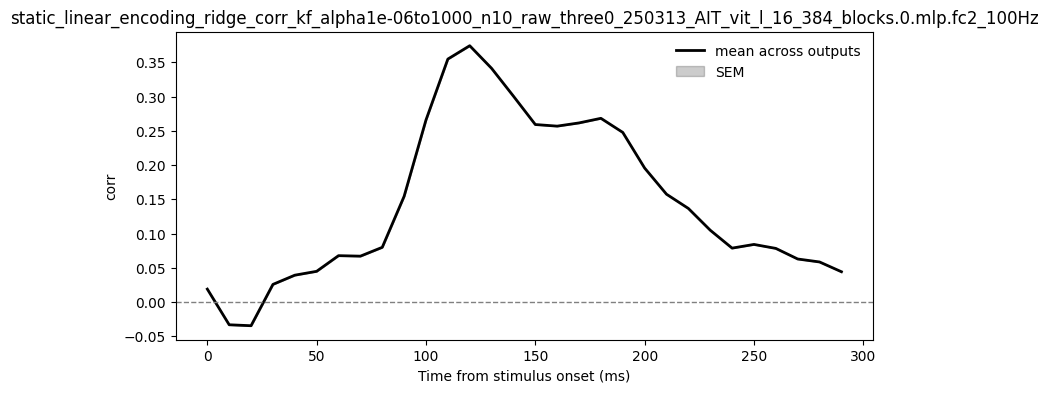

In [46]:
mean_score = np.nanmean(scores, axis=0)
sem_score = np.nanstd(scores, axis=0) / np.sqrt(np.sum(np.isfinite(scores), axis=0))

fig, axis = plt.subplots(figsize=(9, 4))
axis.plot(time_ms, mean_score, color='black', lw=2, label='mean across outputs')
axis.fill_between(time_ms, mean_score - sem_score, mean_score + sem_score, color='black', alpha=0.2, label='SEM')
axis.axhline(0, color='0.5', lw=1, ls='--')
axis.set(xlabel='Time from stimulus onset (ms)', ylabel=score_type, title=result_file.stem)
axis.legend(frameon=False)
plt.show()

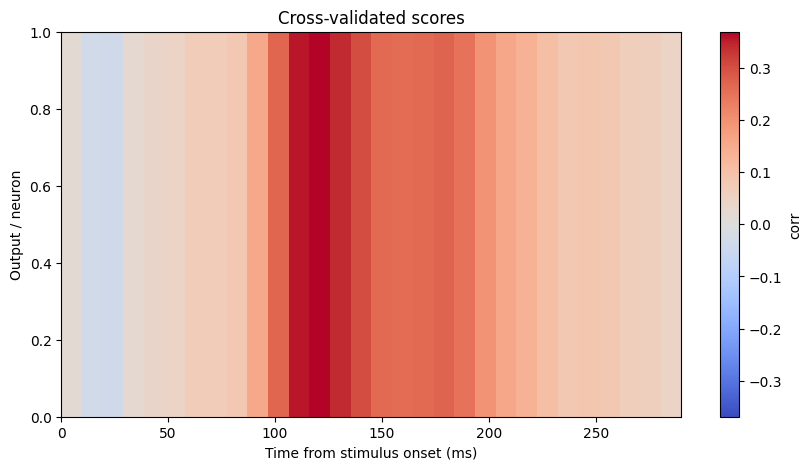

In [47]:
# This is most useful for R², where rows correspond to neurons.
vmax = np.nanpercentile(np.abs(scores), 99)
fig, axis = plt.subplots(figsize=(10, 5))
image = axis.imshow(
    scores, aspect='auto', origin='lower', cmap='coolwarm', vmin=-vmax, vmax=vmax,
    extent=(time_ms[0], time_ms[-1], 0, scores.shape[0]),
)
axis.set(xlabel='Time from stimulus onset (ms)', ylabel='Output / neuron', title='Cross-validated scores')
fig.colorbar(image, ax=axis, label=score_type)
plt.show()

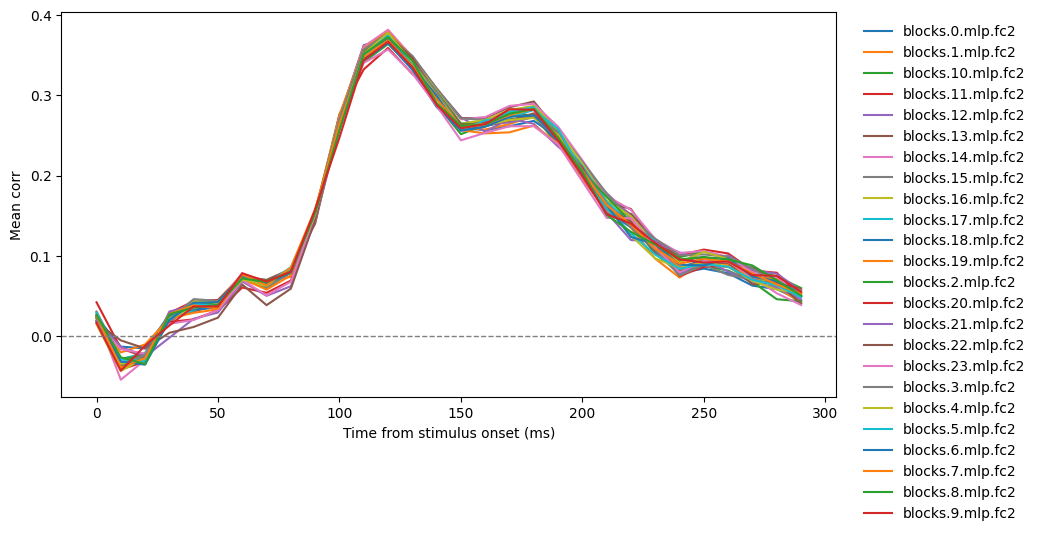

In [48]:
# Compare the mean time course across all matching layers.
fig, axis = plt.subplots(figsize=(10, 5))
for result_file in result_files:
    layer_scores = np.load(result_file)['arr_0']
    if layer_scores.ndim == 1:
        layer_scores = layer_scores[None, :]
    layer_time_ms = np.arange(layer_scores.shape[-1]) * 1000 / new_fs
    layer_name = result_file.stem.rsplit(f'_{new_fs}Hz', 1)[0].rsplit("_", 1)[-1]
    axis.plot(layer_time_ms, np.nanmean(layer_scores, axis=0), lw=1.5, label=layer_name)
axis.axhline(0, color='0.5', lw=1, ls='--')
axis.set(xlabel='Time from stimulus onset (ms)', ylabel=f'Mean {score_type}')
axis.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.show()

For valid cross-validated R², use k-fold CV. Leave-one-out has one held-out image per fold, for which R² is undefined.